# DNA Sequence Classification using Recurrent Neural Networks

This project investigates the relative contribution of **sequential context** versus **local compositional structure** in classifying 100 bp genomic windows by biological origin (Human, Bacteria, Virus, Plant). A systematic five-model comparison is used: a chance baseline, a classical bag-of-k-mers model, a non-recurrent deep baseline, and two recurrent architectures of increasing complexity.

Five models are compared:
1. Dummy Classifier — chance baseline
2. 1D CNN — non-recurrent deep baseline (local motif detection)
3. LSTM — primary recurrent model
4. Bidirectional LSTM — reads both DNA strands
5. N-gram + Naïve Bayes — classical compositional baseline (k-mer counts, no positional awareness)

Real sequences are sourced from NCBI RefSeq. Each genome is split into overlapping 100 bp windows (stride=25 bp, 75 bp overlap between consecutive windows); windows with >10% ambiguous bases are discarded. The final dataset contains 10,000 sequences across 4 classes.


## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
import warnings
import os
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Global seed set to {SEED} — results are reproducible.")


TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Global seed set to 42 — results are reproducible.


## 2. Data Loading

Load the pre-built dataset from Google Drive (or local working directory if running offline).

In [ ]:
import os
import pandas as pd

try:
    from google.colab import drive
    print("Connecting to Google Drive...")
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab. Skipping Google Drive mount.")

CSV_NAME = 'dna_dataset_refseq_L.csv'

def _find_csv(name):
    try:
        local_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        local_dir = os.getcwd()

    local_path = os.path.join(local_dir, name)
    if os.path.exists(local_path):
        return local_path

    drive_path = os.path.join('/content/drive/MyDrive', name)
    if os.path.exists(drive_path):
        return drive_path

    return None

CSV_PATH = _find_csv(CSV_NAME)

if CSV_PATH is None:
    raise FileNotFoundError(
        f'\n{CSV_NAME} was not found.\n'
        f'  Place it in one of these locations and re-run:\n'
        f'  1. Next to this notebook (local PC or Colab cwd)\n'
        f'  2. Directly in your main Google Drive folder ("My Drive") without any subfolders\n'
    )

df = pd.read_csv(CSV_PATH)
print(f'\nSuccess! Loaded dataset from: {CSV_PATH}')
print(f'Shape: {df.shape}')
print(f'\nClass distribution:\n{df["Class_Label"].value_counts()}')

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Success! Loaded dataset from: /content/drive/MyDrive/dna_dataset_refseq_L.csv
Shape: (10000, 9)

Class distribution:
Class_Label
Plant       3000
Bacteria    3000
Human       3000
Virus       1000
Name: count, dtype: int64


Dataset loaded. `df` is ready for EDA and preprocessing.

In [ ]:
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (10000, 9)
Columns: ['Sequence', 'Class_Label', 'GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']


,Sequence,Class_Label,GC_Content,AT_Content,Num_A,Num_T,Num_C,Num_G,kmer_3_freq
0,TAACGTCGTTATAAACGTCCCTATGTATAWACTATAWATAGCAACG...,Plant,37.0,59.0,30,29,24,13,0.081633
1,TGGGGAGGTATAATGAATGGGGAGGTATAATTTGACAGACATTGAC...,Bacteria,54.0,46.0,26,20,11,43,0.112245
2,GGGGCGGATGCTTTACCCGCCCATAGGGCGGCGGGGCGGTAGCCGC...,Human,57.0,43.0,24,19,24,33,0.071429
3,CCTGATATAATTTATAATTTTATAATTTGGGAGGCTTGGTATAATT...,Bacteria,29.0,71.0,33,38,10,19,0.081633
4,AAGAGAAAGGAGACTATAATAAGGATTTATAATACCTGCTTGACAA...,Bacteria,37.0,63.0,33,30,17,20,0.051020


## 3. Exploratory Data Analysis

Quick look at class distribution and sequence-level features. These derived features (GC content, k-mer freq, etc.) are for understanding only — the models take raw one-hot encoded sequences as input.

In [ ]:
print("=== dataset overview ===")
print(f"total samples: {len(df)}")
print(f"sequence length range: {df['Sequence'].str.len().min()} – {df['Sequence'].str.len().max()} bp")
print(f"\nmissing values:\n{df.isnull().sum()}")
print(f"\ndata types:\n{df.dtypes}")

=== dataset overview ===
total samples: 10000
sequence length range: 100 – 100 bp

missing values:
Sequence       0
Class_Label    0
GC_Content     0
AT_Content     0
Num_A          0
Num_T          0
Num_C          0
Num_G          0
kmer_3_freq    0
dtype: int64

data types:
Sequence        object
Class_Label     object
GC_Content     float64
AT_Content     float64
Num_A            int64
Num_T            int64
Num_C            int64
Num_G            int64
kmer_3_freq    float64
dtype: object


=== class distribution ===
Class_Label
Plant       3000
Bacteria    3000
Human       3000
Virus       1000
Name: count, dtype: int64

proportions:
Class_Label
Plant       0.3
Bacteria    0.3
Human       0.3
Virus       0.1
Name: proportion, dtype: float64


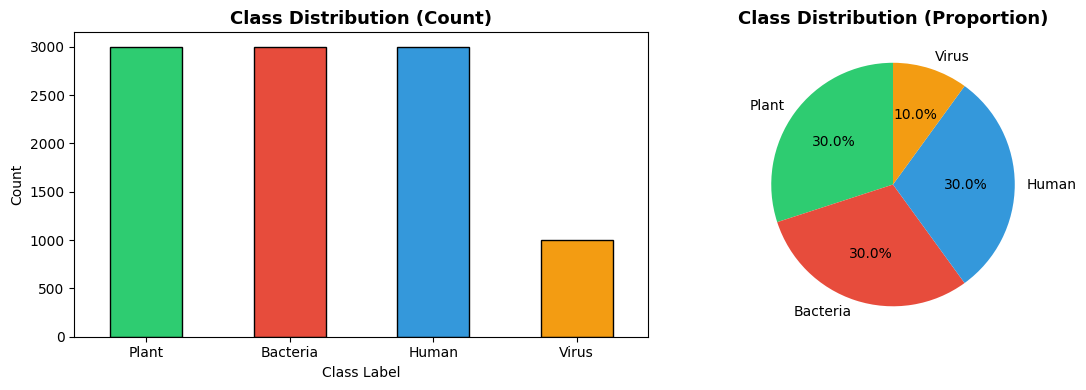

In [ ]:
class_counts = df['Class_Label'].value_counts()
print("=== class distribution ===")
print(class_counts)
print(f"\nproportions:\n{df['Class_Label'].value_counts(normalize=True).round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colours = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

class_counts.plot(kind='bar', ax=axes[0], color=colours, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colours, startangle=90)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df['seq_len_check'] = df['Sequence'].str.len()
print(f"length check — min: {df['seq_len_check'].min()}, max: {df['seq_len_check'].max()}")
print(f"all sequences exactly 100 bp: {(df['seq_len_check'] == 100).all()}")
df.drop(columns=['seq_len_check'], inplace=True)

length check — min: 100, max: 100
all sequences exactly 100 bp: True


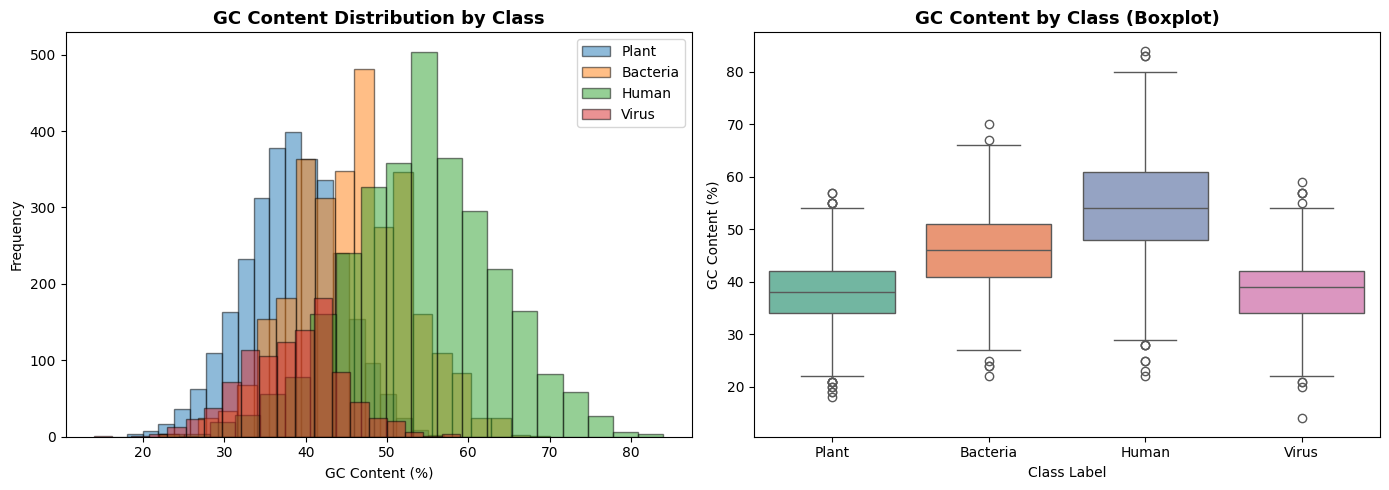


mean GC content per class:
Class_Label
Bacteria    45.65
Human       54.26
Plant       38.31
Virus       38.29
Name: GC_Content, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in df['Class_Label'].unique():
    subset = df[df['Class_Label'] == label]
    axes[0].hist(subset['GC_Content'], bins=20, alpha=0.5, label=label, edgecolor='black')
axes[0].set_title('GC Content Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('GC Content (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x='Class_Label', y='GC_Content', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('GC Content by Class (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class Label')
axes[1].set_ylabel('GC Content (%)')

plt.tight_layout()
plt.show()

print("\nmean GC content per class:")
print(df.groupby('Class_Label')['GC_Content'].mean().round(2))

=== mean nucleotide counts per class ===
             Num_A  Num_T  Num_C  Num_G
Class_Label                            
Bacteria     28.55  25.79  15.91  29.74
Human        25.61  20.14  27.06  27.19
Plant        32.20  26.70  23.32  14.99
Virus        32.94  28.77  21.14  17.14


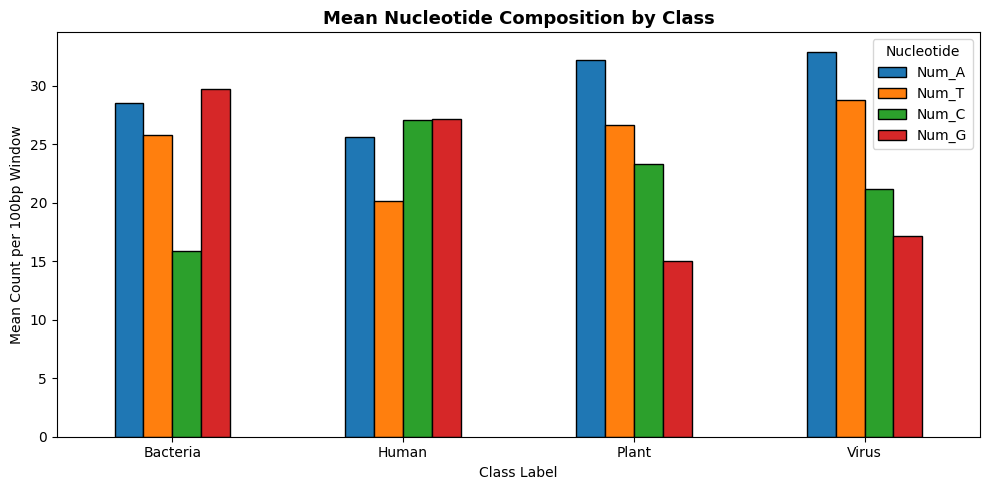

In [ ]:
nuc_cols  = ['Num_A', 'Num_T', 'Num_C', 'Num_G']
nuc_means = df.groupby('Class_Label')[nuc_cols].mean()
print("=== mean nucleotide counts per class ===")
print(nuc_means.round(2))

nuc_means.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Mean Nucleotide Composition by Class', fontsize=13, fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Mean Count per 100bp Window')
plt.legend(title='Nucleotide')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

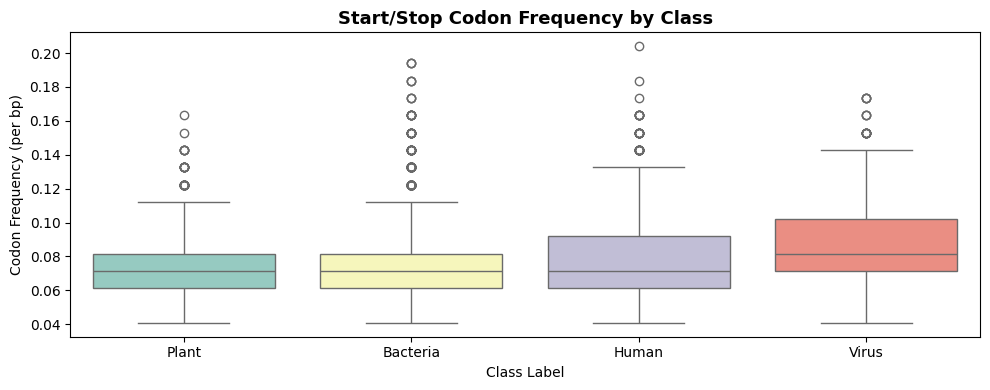

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x='Class_Label', y='kmer_3_freq', data=df, palette='Set3', ax=ax)
ax.set_title('Start/Stop Codon Frequency by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Class Label')
ax.set_ylabel('Codon Frequency (per bp)')
plt.tight_layout()
plt.show()

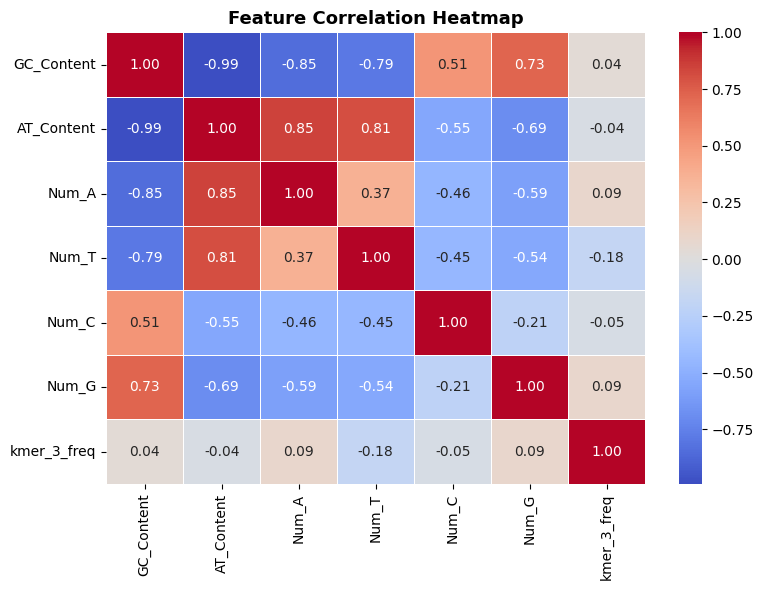

In [ ]:
numeric_cols = ['GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model Selection — Justification

A number of approaches were evaluated before settling on the final model set.

**Approaches excluded:**

| Approach | Reason for exclusion |
|---|---|
| Hidden Markov Models | limited long-range dependency modelling, needs manual state design |
| GRU | comparable to LSTM on short sequences but less studied in this context |
| Transformer | needs far more data; would overfit badly at this dataset size |

**Approaches included:**

| Approach | Role and rationale |
|---|---|
| N-gram + Naïve Bayes | classical compositional baseline — extracts character k-mer counts (k=3,4,5) from the raw sequence string with no positional awareness. benchmarks how much of the classification signal comes from simple k-mer statistics vs. sequential ordering learned by the deep models |
| 1D CNN | non-recurrent deep baseline — convolutional filters detect local nucleotide motifs; GlobalMaxPooling discards all positional information. directly tests whether sequential context adds anything beyond local motif detection |
| LSTM | primary recurrent model — DNA is ordered, and LSTMs maintain hidden state across the full sequence, capturing dependencies that span many nucleotides |
| Bidirectional LSTM | enhanced recurrent model — runs two LSTMs in opposite directions. genes can be encoded on either strand, so bidirectional reading captures complementary patterns without needing separate reverse-complement inputs |

Note on encoding: the n-gram/Naïve Bayes pipeline uses character k-mer counts from the raw sequence string — one-hot encoding is not applicable here. all deep learning models receive raw one-hot encoded sequences so no false ordinal relationship between bases is introduced.

**LSTM** was chosen as the primary model — DNA is ordered, and LSTMs maintain state across the full sequence, capturing patterns that span many nucleotides.

**BiLSTM** is a natural extension — genes can be encoded on either strand, so reading both directions without explicit reverse complement augmentation makes biological sense.

**1D CNN** is kept as a non-recurrent baseline. Comparing CNN vs LSTM directly tests whether sequential context adds anything beyond local motif detection.

Model sizes are kept small on purpose — with ~8,000 training sequences, large models overfit quickly.

| Model | Params |
|---|---|
| 1D CNN | ~3,800 |
| LSTM | ~5,500 |
| BiLSTM | ~9,700 |


## 5. Preprocessing

Each nucleotide is one-hot encoded to a 4D vector: A=[1,0,0,0], T=[0,1,0,0], C=[0,0,1,0], G=[0,0,0,1]. Ambiguous bases get [0.25, 0.25, 0.25, 0.25]. Each 100 bp sequence becomes shape (100, 4).

Windows are extracted with a stride of 25 bp (75 bp overlap between consecutive windows). The overlap means near-identical sequences from the same genome could appear in both train and test if split randomly — this is why the split is done at the **genome level**: all windows from a given genome go to either train or test, never both. This prevents data leakage that would artificially inflate test accuracy.


In [ ]:
WINDOW_SIZE    = 100
STRIDE         = 25
MAX_AMBIG_FRAC = 0.10

STANDARD_BASES = set('ATCG')

AMBIG_ENCODING = np.array([0.25, 0.25, 0.25, 0.25], dtype=np.float32)
BASE_ENCODING  = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

def ambig_fraction(sequence):
    n_ambig = sum(1 for b in sequence.upper() if b not in STANDARD_BASES)
    return n_ambig / len(sequence)

def one_hot_encode(sequence):
    encoding = np.zeros((len(sequence), 4), dtype=np.float32)
    for i, nuc in enumerate(sequence.upper()):
        if nuc in BASE_ENCODING:
            encoding[i, BASE_ENCODING[nuc]] = 1.0
        else:
            encoding[i] = AMBIG_ENCODING
    return encoding

def sliding_windows(sequence, window=WINDOW_SIZE, stride=STRIDE):
    windows = []
    for start in range(0, len(sequence) - window + 1, stride):
        w = sequence[start:start + window]
        if ambig_fraction(w) <= MAX_AMBIG_FRAC:
            windows.append(w)
    return windows

df = df[df['Sequence'].apply(lambda s: ambig_fraction(s) <= MAX_AMBIG_FRAC)].reset_index(drop=True)
print(f"sequences after ambiguity filter: {len(df)}")
print(f"ambiguous-base windows removed: this is sequences that had >{int(MAX_AMBIG_FRAC*100)}% non-ATCG bases")

def encode_sequences(sequences):
    return np.array([one_hot_encode(seq) for seq in sequences])

X = encode_sequences(df['Sequence'].values)
print(f"\nencoded shape: {X.shape}  — (samples, timesteps, features)")

le = LabelEncoder()
y_int = le.fit_transform(df['Class_Label'].values)
class_names = le.classes_
print(f"classes: {class_names}")
print(f"label encoding: {dict(zip(class_names, le.transform(class_names)))}")

y = keras.utils.to_categorical(y_int, num_classes=4)
print(f"one-hot labels shape: {y.shape}")

sequences after ambiguity filter: 10000
ambiguous-base windows removed: this is sequences that had >10% non-ATCG bases

encoded shape: (10000, 100, 4)  — (samples, timesteps, features)
classes: ['Bacteria' 'Human' 'Plant' 'Virus']
label encoding: {'Bacteria': np.int64(0), 'Human': np.int64(1), 'Plant': np.int64(2), 'Virus': np.int64(3)}
one-hot labels shape: (10000, 4)


In [ ]:
# genome-level split — ensures no genome contributes windows to both train and test
# this prevents data leakage where near-identical windows from the same genome
# appear in both splits, which was inflating CNN test accuracy

# get unique genome ids per class (using the source accession stored in df)
# if the csv doesn't have an accession column we approximate by grouping on class
# and hashing the first 20 chars of each sequence as a proxy genome id

if 'Accession' in df.columns:
    genome_col = 'Accession'
else:
    # approximate: first 20 chars tends to be unique per source genome in RefSeq windows
    df['genome_id'] = df['Sequence'].str[:20] + '_' + df['Class_Label']
    genome_col = 'genome_id'

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df[genome_col].values

train_idx, test_idx = next(gss.split(X, y_int, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
y_train_int = y_int[train_idx]
y_test_int  = y_int[test_idx]

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'\ntrain class distribution: {np.bincount(y_train_int)}')
print(f'test class distribution:  {np.bincount(y_test_int)}')

np.save('X_train.npy', X_train)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy',  y_test)
print('\npreprocessed arrays saved.')

X_train: (8000, 100, 4)
X_test:  (2000, 100, 4)

train class distribution: [2397 2394 2416  793]
test class distribution:  [603 606 584 207]

preprocessed arrays saved.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train_int,
    random_state=42
)
y_tr_int  = np.argmax(y_tr,  axis=1)
y_val_int = np.argmax(y_val, axis=1)

idx      = np.random.permutation(len(X_tr))
X_tr     = X_tr[idx]
y_tr     = y_tr[idx]
y_tr_int = y_tr_int[idx]

weights           = compute_class_weight('balanced', classes=np.unique(y_tr_int), y=y_tr_int)
class_weight_dict = dict(enumerate(weights))

BATCH_SIZE = 32
EPOCHS     = 50

print(f'X_tr: {X_tr.shape}  X_val: {X_val.shape}')
print(f'class weights: {class_weight_dict}')

X_tr: (7200, 100, 4)  X_val: (800, 100, 4)
class weights: {0: np.float64(0.8344923504867872), 1: np.float64(0.8352668213457076), 2: np.float64(0.827966881324747), 3: np.float64(2.5210084033613445)}


### reverse complement augmentation

each training sequence is paired with its reverse complement, doubling the training set without collecting new data.

In [ ]:
def reverse_complement_onehot(X):
    X_rc = []
    for seq in X:
        seq_rev = seq[::-1]
        seq_rc = seq_rev.copy()
        seq_rc[:, 0] = seq_rev[:, 1]
        seq_rc[:, 1] = seq_rev[:, 0]
        seq_rc[:, 2] = seq_rev[:, 3]
        seq_rc[:, 3] = seq_rev[:, 2]
        X_rc.append(seq_rc)
    return np.array(X_rc)

X_train_rc = reverse_complement_onehot(X_tr)
y_train_rc = y_tr.copy()

X_tr_aug = np.concatenate([X_tr, X_train_rc], axis=0)
y_tr_aug = np.concatenate([y_tr, y_train_rc], axis=0)

print(f"original training size: {X_tr.shape[0]}")
print(f"augmented training size: {X_tr_aug.shape[0]}")

original training size: 7200
augmented training size: 14400


## 6. Model 1 — Dummy Classifier (Chance Baseline)

Always predicts the most frequent class. Expected accuracy is ~30% given the class imbalance (Bacteria/Human/Plant at 3000 each, Virus at 1000). Anything learned model must clearly exceed this.

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_flat, y_train_int)
y_pred_dummy = dummy.predict(X_test_flat)

print("=== dummy classifier results ===")
print(classification_report(y_test_int, y_pred_dummy, target_names=class_names))

=== dummy classifier results ===
              precision    recall  f1-score   support

    Bacteria       0.00      0.00      0.00       603
       Human       0.00      0.00      0.00       606
       Plant       0.29      1.00      0.45       584
       Virus       0.00      0.00      0.00       207

    accuracy                           0.29      2000
   macro avg       0.07      0.25      0.11      2000
weighted avg       0.09      0.29      0.13      2000



## 7. Model 2 — 1D CNN (Non-Recurrent Baseline)

Convolutional filters slide over the sequence detecting local nucleotide patterns — functionally similar to k-mer counting. After `GlobalMaxPooling1D` there is no positional memory, so the CNN cannot model dependencies between positions that are far apart. It serves as a baseline to see how much sequential context actually matters.

In [ ]:
def build_cnn(input_shape=(100, 4), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=32, kernel_size=8, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=16, kernel_size=4, activation='relu', padding='same'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 100, 32)        │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 50, 16)         │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 16)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,796 (14.83 KB)

 Trainable params: 3,796 (14.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 50

cnn_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

cnn_history = cnn_model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7354 - loss: 0.8272 - val_accuracy: 0.9750 - val_loss: 0.1572 - learning_rate: 0.0010
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9657 - loss: 0.1400 - val_accuracy: 0.9925 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9828 - loss: 0.0690 - val_accuracy: 0.9937 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9878 - loss: 0.0433 - val_accuracy: 0.9962 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9914 - loss: 0.0326 - val_accuracy: 0.9962 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9929 - loss: 0.0238 - val_accuracy: 0.9937 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9935 - loss: 0.0232 -

## 8. Model 3 — LSTM

Processes the sequence one nucleotide at a time, maintaining hidden state across positions. A single 32-unit layer is kept small to match the dataset size — stacked or wider LSTMs overfit badly here. Dropout(0.3) after the LSTM output, early stopping with best-weight restore.

In [ ]:
def build_lstm(input_shape=(100, 4), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(32),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,868 (19.02 KB)

 Trainable params: 4,868 (19.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
]

lstm_history = lstm_model.fit(
    X_tr_aug, y_tr_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=lstm_callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4231 - loss: 1.1948 - val_accuracy: 0.4650 - val_loss: 1.0409
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5019 - loss: 1.0683 - val_accuracy: 0.4563 - val_loss: 1.1326
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4651 - loss: 1.1454 - val_accuracy: 0.5350 - val_loss: 1.0393
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4432 - loss: 1.1718 - val_accuracy: 0.3288 - val_loss: 1.4287
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4951 - loss: 1.0886 - val_accuracy: 0.5288 - val_loss: 0.9867
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5556 - loss: 0.9845 - val_accuracy: 0.5863 - val_loss: 0.8892
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5874 - loss: 0.9285 - val_accuracy: 0.3100 - val_loss: 1.5621
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5257 - loss: 1.0559 - val_accuracy: 

## 9. Model 4 — Bidirectional LSTM

Two LSTMs running in opposite directions (5'→3' and 3'→5'), outputs concatenated. Captures patterns in either orientation without needing separate reverse complement inputs. Same regularisation as the LSTM.

In [ ]:
def build_bilstm(input_shape=(100, 4), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,732 (38.02 KB)

 Trainable params: 9,732 (38.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
]

bilstm_history = bilstm_model.fit(
    X_tr_aug, y_tr_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=bilstm_callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4567 - loss: 1.1261 - val_accuracy: 0.5375 - val_loss: 0.9135
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5994 - loss: 0.8955 - val_accuracy: 0.5450 - val_loss: 0.8405
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6747 - loss: 0.7697 - val_accuracy: 0.6662 - val_loss: 0.6602
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7190 - loss: 0.7015 - val_accuracy: 0.7462 - val_loss: 0.5867
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7405 - loss: 0.6587 - val_accuracy: 0.7188 - val_loss: 0.5610
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7678 - loss: 0.6196 - val_accuracy: 0.7588 - val_loss: 0.5271
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8035 - loss: 0.5675 - val_accuracy: 0.8537 - val_loss: 0.3872
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8357 - loss: 0.4893 - val_accu

## 10. Model 5 — N-gram + Naïve Bayes

Character n-grams (tri-, tetra-, and penta-grams, k=3–5) are extracted from each raw sequence
string using sklearn's `CountVectorizer(analyzer='char')` and fed into a `MultinomialNB` classifier.

This is a classical bag-of-k-mers approach — it captures local compositional patterns but
ignores long-range positional context. It benchmarks how much of the classification signal
comes from simple k-mer statistics vs. sequential ordering learned by the deep models.

In [ ]:
# n-gram + naïve bayes classifier (model 5)
# uses raw sequence strings — CountVectorizer handles all tokenisation
# ngram_range=(3,5) extracts all tri/tetra/penta-gram character subsequences

# pull raw sequence strings using the same genome-level train/test indices
seqs_all   = df['Sequence'].values
seqs_train = seqs_all[train_idx]
seqs_test  = seqs_all[test_idx]

# pipeline: char n-gram counts → multinomial naïve bayes
nb_pipeline = Pipeline([
    ('ngram', CountVectorizer(analyzer='char', ngram_range=(3, 5))),
    ('clf',   MultinomialNB())
])

nb_pipeline.fit(seqs_train, y_train_int)
y_pred_nb = nb_pipeline.predict(seqs_test)

print('=== n-gram naïve bayes results ===')
print(classification_report(y_test_int, y_pred_nb, target_names=class_names))


=== n-gram naïve bayes results ===
              precision    recall  f1-score   support

    Bacteria       1.00      1.00      1.00       603
       Human       1.00      1.00      1.00       606
       Plant       1.00      1.00      1.00       584
       Virus       1.00      1.00      1.00       207

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## 10.1 N-gram Ablation — Effect of k-mer Length

The choice of `ngram_range=(3,5)` above was not justified empirically. This cell tests six configurations to identify which k-mer lengths drive the classification signal. Codons are triplets (k=3), so k=3 alone has direct biological motivation; longer k-mers capture more context at the cost of sparsity.

=== n-gram ablation (macro F1 on held-out test set) ===

Config                Accuracy  F1 (macro)  Per-class F1
---------------------------------------------------------------------------
k=2 only                0.9760      0.9715  Bacteria=0.9754  Human=0.9662  Plant=0.9974  Virus=0.9471
k=3 only                0.9955      0.9959  Bacteria=0.9934  Human=0.9925  Plant=1.0000  Virus=0.9976
k=4 only                0.9995      0.9996  Bacteria=0.9992  Human=0.9992  Plant=1.0000  Virus=1.0000
k=5 only                0.9995      0.9996  Bacteria=0.9992  Human=0.9992  Plant=1.0000  Virus=1.0000
k=3–5 (current)         0.9995      0.9996  Bacteria=0.9992  Human=0.9992  Plant=1.0000  Virus=1.0000


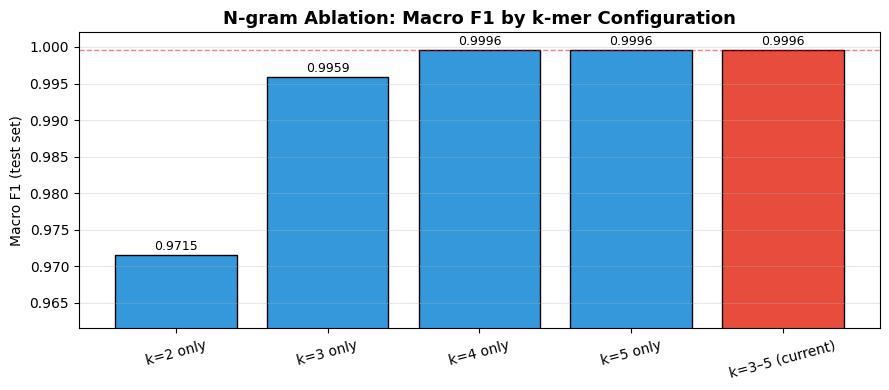


best config: k=4 only  (macro F1 = 0.9996)
k=3 alone:  macro F1 = 0.9959  (trails k=3–5)


In [ ]:
# n-gram ablation: test different k-mer length configurations
# seqs_train / seqs_test and y_train_int / y_test_int are already defined above

ngram_configs = {
    'k=2 only':   (2, 2),
    'k=3 only':   (3, 3),
    'k=4 only':   (4, 4),
    'k=5 only':   (5, 5),
    'k=3–5 (current)': (3, 5),
}

ablation_results = {}

print("=== n-gram ablation (macro F1 on held-out test set) ===\n")
print(f"{'Config':<20} {'Accuracy':>9} {'F1 (macro)':>11}  Per-class F1")
print("-" * 75)

for label, ngram_range in ngram_configs.items():
    pipe = Pipeline([
        ('ngram', CountVectorizer(analyzer='char', ngram_range=ngram_range)),
        ('clf',   MultinomialNB())
    ])
    pipe.fit(seqs_train, y_train_int)
    preds = pipe.predict(seqs_test)

    acc    = accuracy_score(y_test_int, preds)
    f1_mac = f1_score(y_test_int, preds, average='macro', zero_division=0)
    f1_per = f1_score(y_test_int, preds, average=None, zero_division=0)

    ablation_results[label] = {'accuracy': acc, 'f1_macro': f1_mac, 'f1_per_class': f1_per}

    per_class_str = '  '.join([f"{class_names[i]}={f1_per[i]:.4f}" for i in range(len(class_names))])
    print(f"{label:<20} {acc:>9.4f} {f1_mac:>11.4f}  {per_class_str}")

# plot
fig, ax = plt.subplots(figsize=(9, 4))
labels  = list(ablation_results.keys())
f1s     = [ablation_results[k]['f1_macro'] for k in labels]
colors  = ['#e74c3c' if k == 'k=3–5 (current)' else '#3498db' for k in labels]

bars = ax.bar(labels, f1s, color=colors, edgecolor='black')
ax.set_ylim(min(f1s) - 0.01, 1.002)
ax.set_ylabel('Macro F1 (test set)')
ax.set_title('N-gram Ablation: Macro F1 by k-mer Configuration', fontsize=13, fontweight='bold')
ax.axhline(y=f1s[labels.index('k=3–5 (current)')], color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_config = max(ablation_results, key=lambda k: ablation_results[k]['f1_macro'])
print(f"\nbest config: {best_config}  (macro F1 = {ablation_results[best_config]['f1_macro']:.4f})")
print(f"k=3 alone:  macro F1 = {ablation_results['k=3 only']['f1_macro']:.4f}  "
      f"({'matches' if abs(ablation_results['k=3 only']['f1_macro'] - ablation_results['k=3–5 (current)']['f1_macro']) < 0.002 else 'trails'} k=3–5)")

## 11. Save Trained Models


In [ ]:
import joblib

cnn_model.save('cnn_model.keras')
lstm_model.save('lstm_model.keras')
bilstm_model.save('bilstm_model.keras')

# save the n-gram pipeline too — joblib handles sklearn pipelines cleanly
joblib.dump(nb_pipeline, 'nb_pipeline.joblib')

print("all models saved.")


all models saved.


## 12. Training Curves

Training and validation accuracy/loss per epoch for each deep learning model.

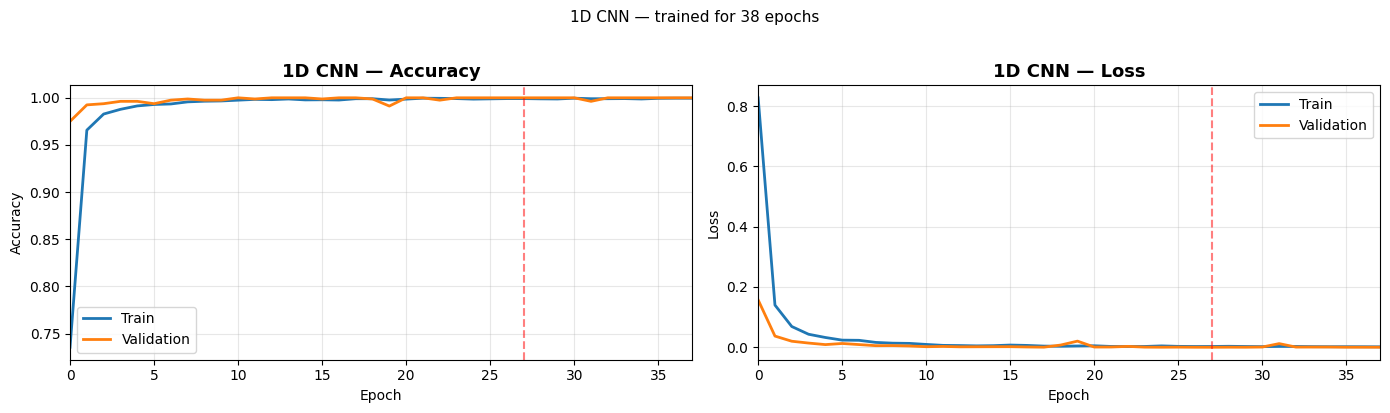

  best val loss at epoch 28/38 — val acc: 1.0000



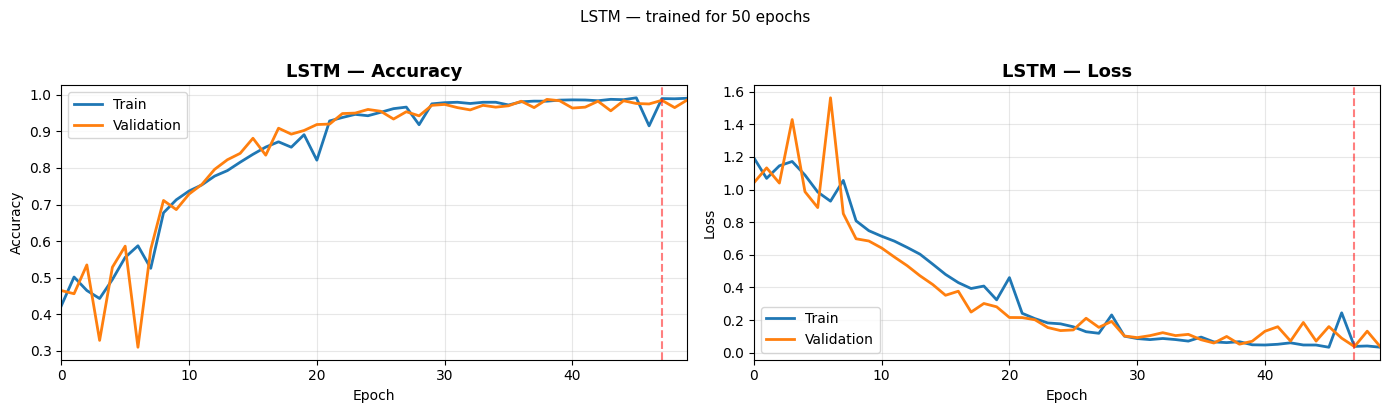

  best val loss at epoch 48/50 — val acc: 0.9850



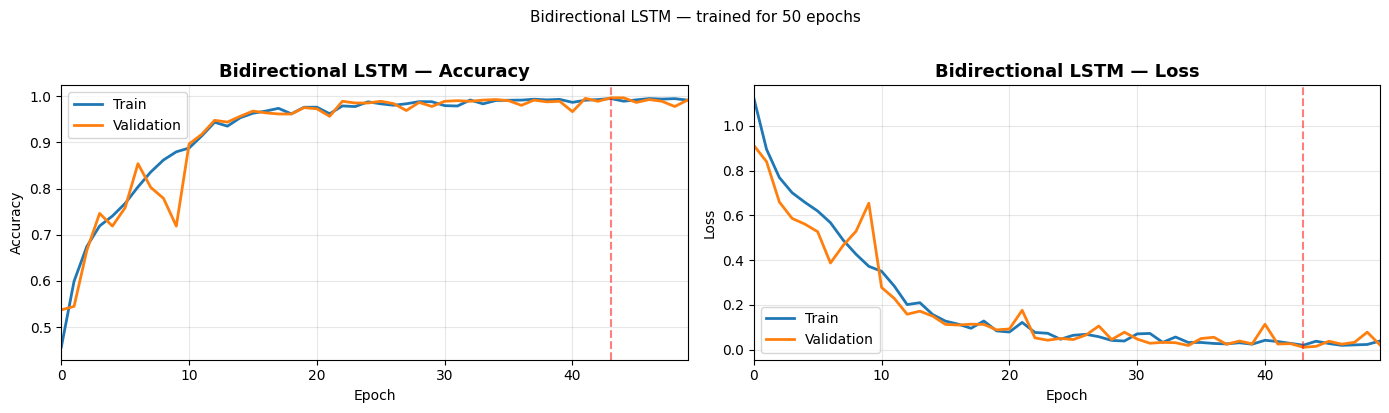

  best val loss at epoch 44/50 — val acc: 0.9962



In [ ]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    epochs_ran = len(history.history['accuracy'])

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, epochs_ran - 1)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, epochs_ran - 1)

    best_epoch = np.argmin(history.history['val_loss'])
    for ax in axes:
        ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch+1})')

    plt.suptitle(f'{model_name} — trained for {epochs_ran} epochs', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"  best val loss at epoch {best_epoch+1}/{epochs_ran} — val acc: {history.history['val_accuracy'][best_epoch]:.4f}\n")

plot_training_curves(cnn_history,    '1D CNN')
plot_training_curves(lstm_history,   'LSTM')
plot_training_curves(bilstm_history, 'Bidirectional LSTM')

## 13a. Evaluation — Per-Model Results

All models evaluated on the held-out test set (sequences from genomes not seen during training).

In [ ]:
y_pred_cnn    = np.argmax(cnn_model.predict(X_test),    axis=1)
y_pred_lstm   = np.argmax(lstm_model.predict(X_test),   axis=1)
y_pred_bilstm = np.argmax(bilstm_model.predict(X_test), axis=1)
# nb predictions were computed in section 10 — reconfirm here
y_pred_nb     = nb_pipeline.predict(seqs_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
models_preds = {
    'Dummy Classifier':      y_pred_dummy,
    '1D CNN':                y_pred_cnn,
    'LSTM':                  y_pred_lstm,
    'Bidirectional LSTM':    y_pred_bilstm,
    'N-gram + Naïve Bayes':  y_pred_nb
}

for name, preds in models_preds.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test_int, preds, target_names=class_names))


  Dummy Classifier
              precision    recall  f1-score   support

    Bacteria       0.00      0.00      0.00       603
       Human       0.00      0.00      0.00       606
       Plant       0.29      1.00      0.45       584
       Virus       0.00      0.00      0.00       207

    accuracy                           0.29      2000
   macro avg       0.07      0.25      0.11      2000
weighted avg       0.09      0.29      0.13      2000


  1D CNN
              precision    recall  f1-score   support

    Bacteria       1.00      1.00      1.00       603
       Human       1.00      1.00      1.00       606
       Plant       1.00      1.00      1.00       584
       Virus       0.99      1.00      0.99       207

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


  LSTM
              precision    recall  f1-score   support

    Bacteria       0.99      0.99    

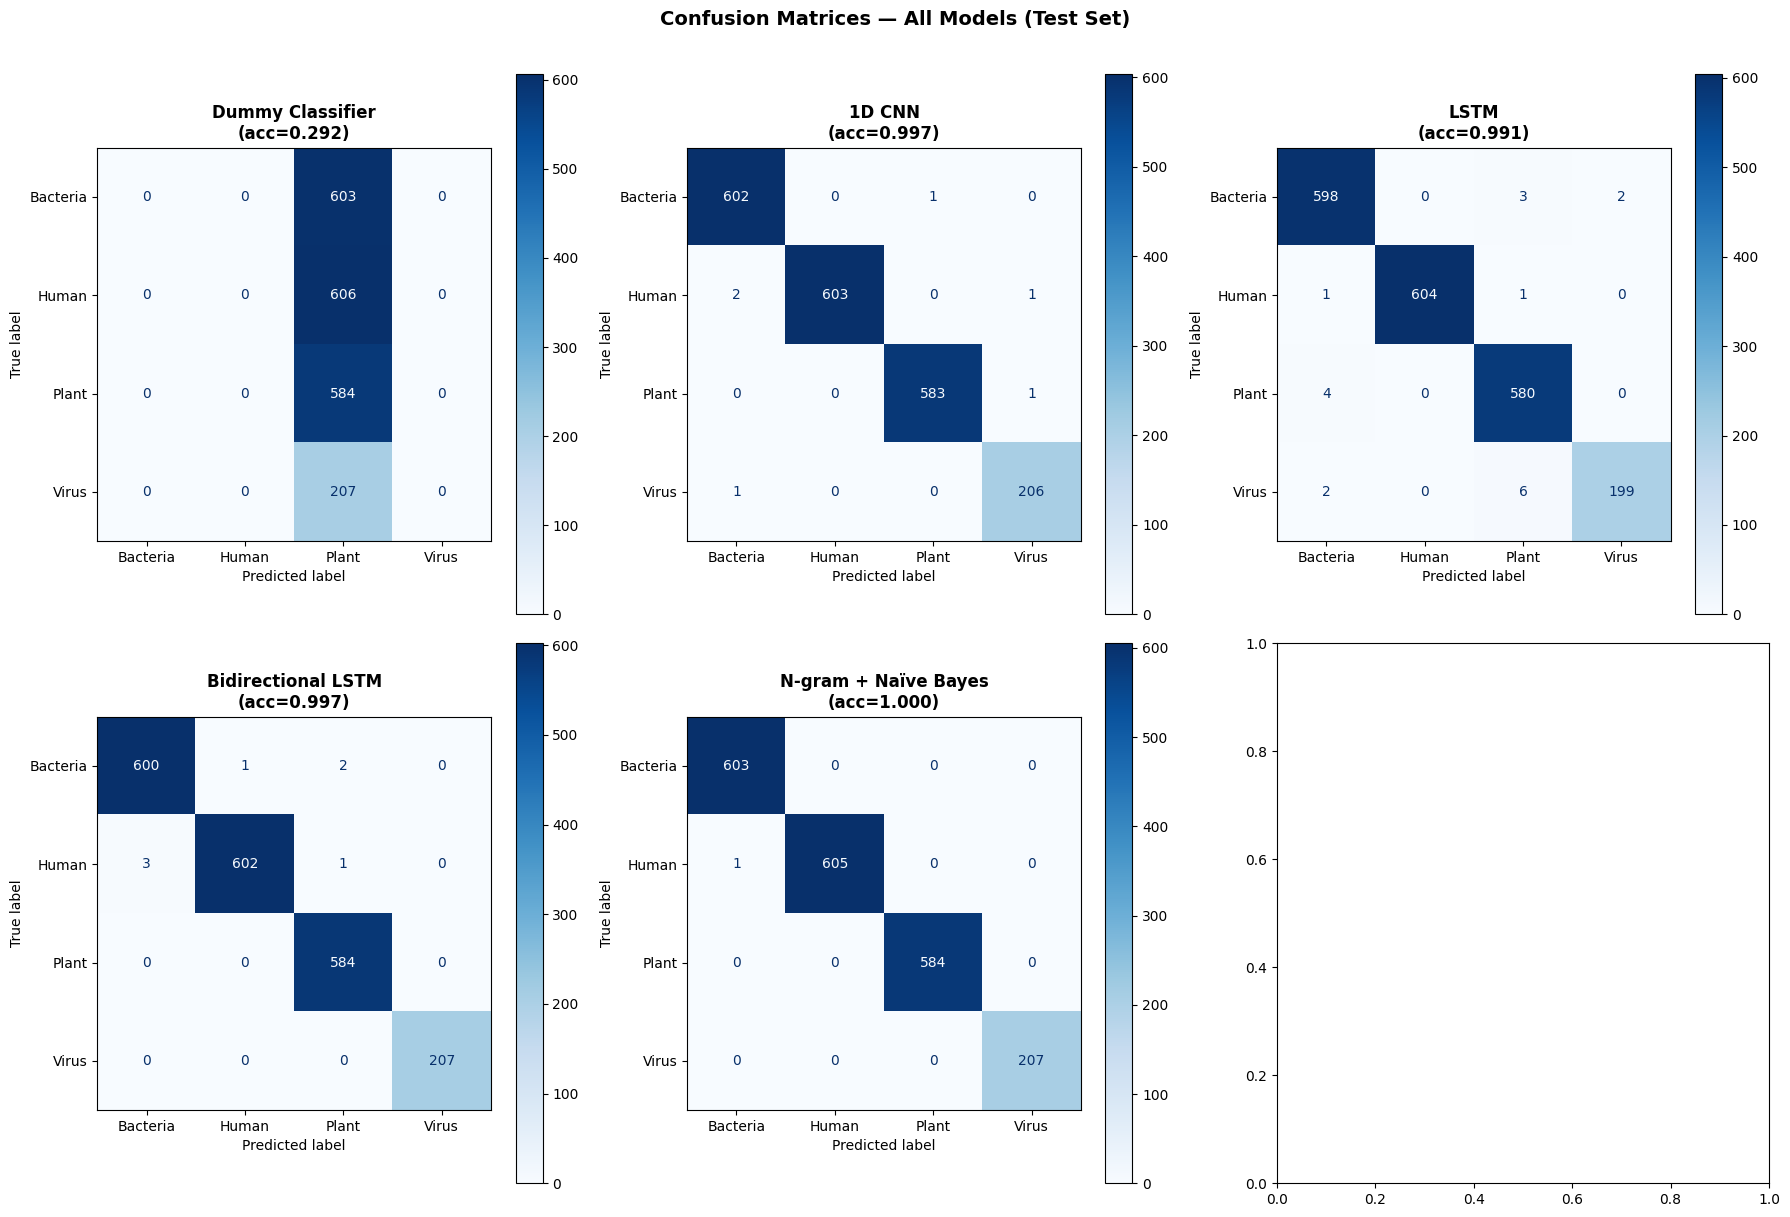

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, preds) in enumerate(models_preds.items()):
    cm   = confusion_matrix(y_test_int, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    acc = accuracy_score(y_test_int, preds)
    axes[idx].set_title(f'{name}\n(acc={acc:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13b. Calibration Analysis (reliability diagrams)

A reliability diagram (calibration curve) answers the question:
"When the model says it is X% confident, is it actually right X% of the time?"

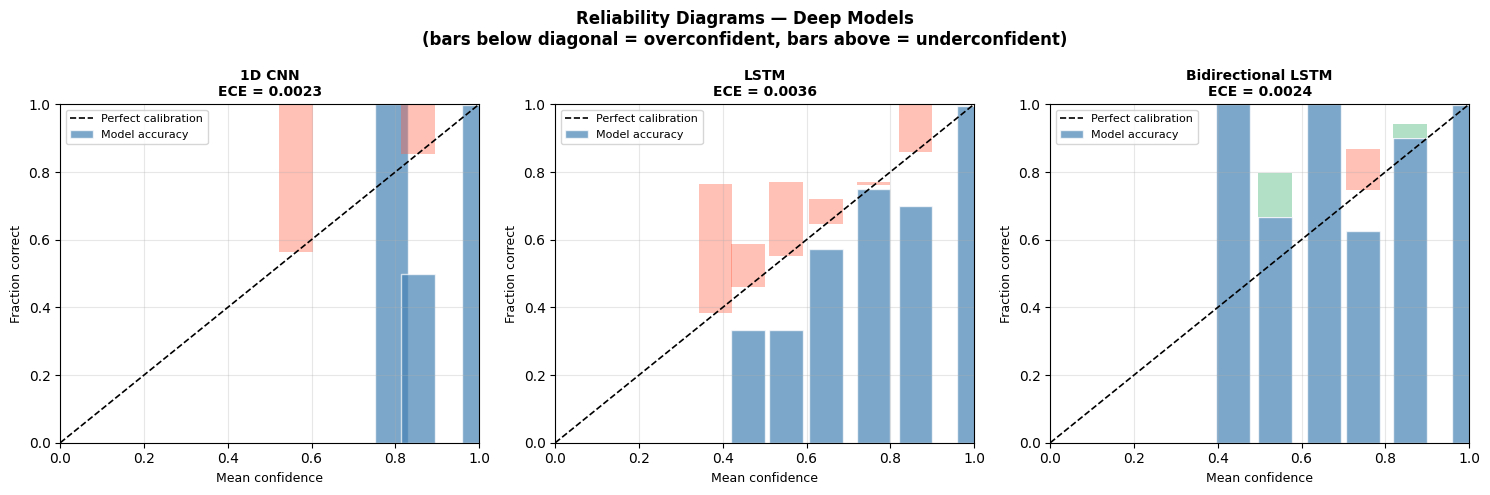


Expected Calibration Error (ECE) — lower is better:
  1D CNN              : 0.0023
  LSTM                : 0.0036
  Bidirectional LSTM  : 0.0024

ECE interpretation:
  < 0.01  : well-calibrated — confidence scores are meaningful
  0.01–0.05: moderate miscalibration
  > 0.05  : significant overconfidence — probabilities should not be trusted directly


In [ ]:
def reliability_diagram(y_true, y_proba, model_name, ax, n_bins=10):
    confidence = np.max(y_proba, axis=1)
    predicted  = np.argmax(y_proba, axis=1)
    correct    = (predicted == np.array(y_true)).astype(float)

    bin_edges    = np.linspace(0, 1, n_bins + 1)
    bin_accs     = []
    bin_confs    = []
    bin_sizes    = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidence >= lo) & (confidence < hi if i < n_bins - 1 else confidence <= hi)
        if mask.sum() == 0:
            continue
        bin_accs.append(correct[mask].mean())
        bin_confs.append(confidence[mask].mean())
        bin_sizes.append(mask.sum())

    bin_accs  = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    bin_sizes = np.array(bin_sizes)

    # Expected Calibration Error is the weighted average of |accuracy - confidence| per bin
    ece = np.sum(bin_sizes * np.abs(bin_accs - bin_confs)) / bin_sizes.sum()

    # plot
    ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.7,
           color='steelblue', edgecolor='white', label='Model accuracy')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfect calibration')

    # gap fill where red = overconfident, green = underconfident
    for bc, ba in zip(bin_confs, bin_accs):
        color = 'tomato' if ba < bc else 'mediumseagreen'
        ax.bar(bc, bc - ba if ba < bc else ba - bc,
               bottom=ba if ba > bc else bc,
               width=0.08, alpha=0.4, color=color)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean confidence', fontsize=9)
    ax.set_ylabel('Fraction correct', fontsize=9)
    ax.set_title(f'{model_name}\nECE = {ece:.4f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    return ece

# raw softmax probabilities
proba_cnn    = cnn_model.predict(X_test,    verbose=0)
proba_lstm   = lstm_model.predict(X_test,   verbose=0)
proba_bilstm = bilstm_model.predict(X_test, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Reliability Diagrams — Deep Models\n'
             '(bars below diagonal = overconfident, bars above = underconfident)',
             fontsize=12, fontweight='bold')

ece_cnn    = reliability_diagram(y_test_int, proba_cnn,    '1D CNN',             axes[0])
ece_lstm   = reliability_diagram(y_test_int, proba_lstm,   'LSTM',               axes[1])
ece_bilstm = reliability_diagram(y_test_int, proba_bilstm, 'Bidirectional LSTM', axes[2])

plt.tight_layout()
plt.savefig('calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExpected Calibration Error (ECE) — lower is better:")
print(f"  1D CNN              : {ece_cnn:.4f}")
print(f"  LSTM                : {ece_lstm:.4f}")
print(f"  Bidirectional LSTM  : {ece_bilstm:.4f}")
print("\nECE interpretation:")
print("  < 0.01  : well-calibrated — confidence scores are meaningful")
print("  0.01–0.05: moderate miscalibration")
print("  > 0.05  : significant overconfidence — probabilities should not be trusted directly")

## 13c. Confidence Distribution — Correct vs Incorrect Predictions

Plots the distribution of max softmax probability, split by whether the prediction was correct (blue) or incorrect (red).


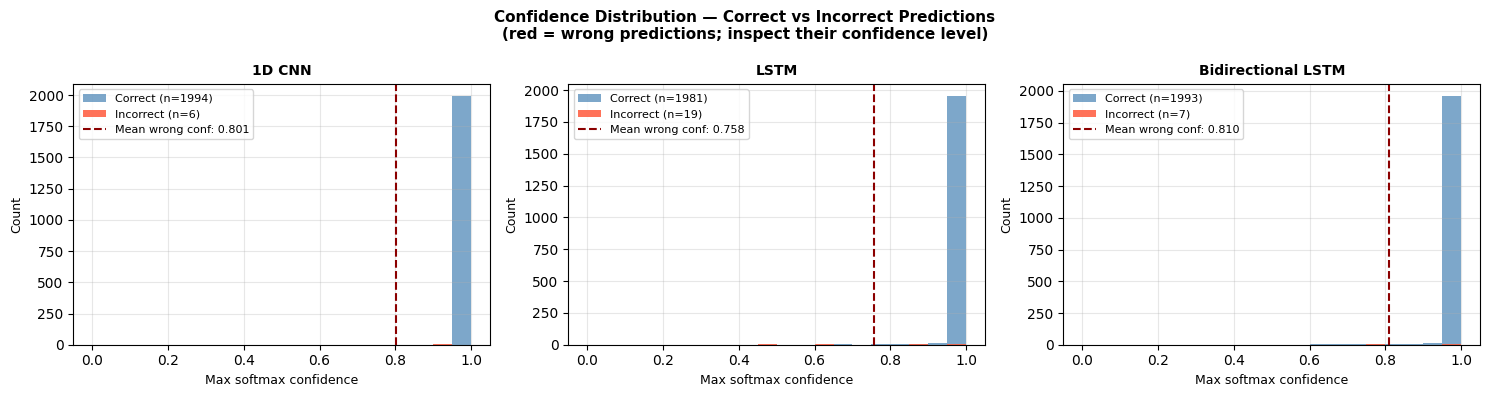


Mean confidence on incorrect predictions:
  1D CNN                : 0.8014  (n=6 wrong predictions)
  LSTM                  : 0.7576  (n=19 wrong predictions)
  Bidirectional LSTM    : 0.8101  (n=7 wrong predictions)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confidence Distribution — Correct vs Incorrect Predictions\n'
             '(red = wrong predictions; inspect their confidence level)',
             fontsize=11, fontweight='bold')

deep_models = [
    ('1D CNN',             proba_cnn,    y_pred_cnn),
    ('LSTM',               proba_lstm,   y_pred_lstm),
    ('Bidirectional LSTM', proba_bilstm, y_pred_bilstm),
]

for ax, (name, proba, preds) in zip(axes, deep_models):
    confidence = np.max(proba, axis=1)
    correct_mask   = (np.array(preds) == np.array(y_test_int))
    incorrect_mask = ~correct_mask

    bins = np.linspace(0, 1, 21)

    ax.hist(confidence[correct_mask],   bins=bins, alpha=0.7,
            color='steelblue', label=f'Correct (n={correct_mask.sum()})')
    ax.hist(confidence[incorrect_mask], bins=bins, alpha=0.9,
            color='tomato',    label=f'Incorrect (n={incorrect_mask.sum()})')

    ax.set_xlabel('Max softmax confidence', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # annotate mean confidence of wrong predictions
    if incorrect_mask.sum() > 0:
        mean_wrong_conf = confidence[incorrect_mask].mean()
        ax.axvline(mean_wrong_conf, color='darkred', linestyle='--', linewidth=1.5,
                   label=f'Mean wrong conf: {mean_wrong_conf:.3f}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('calibration_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean confidence on incorrect predictions:")
for name, proba, preds in deep_models:
    confidence    = np.max(proba, axis=1)
    incorrect_mask = (np.array(preds) != np.array(y_test_int))
    n_wrong = incorrect_mask.sum()
    if n_wrong > 0:
        print(f"  {name:<22}: {confidence[incorrect_mask].mean():.4f}  "
              f"(n={n_wrong} wrong predictions)")
    else:
        print(f"  {name:<22}: no incorrect predictions")

## 14. Comparative Summary

Side-by-side comparison of all five models. Final test-set metrics are reported alongside
3-fold cross-validation results (mean ± std F1) for the three learned models.
CV is run on the full dataset using GroupKFold so no genome leaks across folds.


In [ ]:
# final test-set metrics (same as before)
results = []
for name, preds in models_preds.items():
    results.append({
        'Model':             name,
        'Accuracy':          accuracy_score(y_test_int, preds),
        'Precision (macro)': precision_score(y_test_int, preds, average='macro', zero_division=0),
        'Recall (macro)':    recall_score(y_test_int,    preds, average='macro', zero_division=0),
        'F1-Score (macro)':  f1_score(y_test_int,        preds, average='macro', zero_division=0)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("=== model comparison (test set) ===")
print(results_df.to_string())
results_df


=== model comparison (test set) ===
                      Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Model                                                                              
Dummy Classifier        0.2920             0.0730          0.2500            0.1130
1D CNN                  0.9970             0.9959          0.9967            0.9963
LSTM                    0.9905             0.9904          0.9857            0.9880
Bidirectional LSTM      0.9965             0.9971          0.9971            0.9971
N-gram + Naïve Bayes    0.9995             0.9996          0.9996            0.9996


,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Model,,,,
Dummy Classifier,0.2920,0.0730,0.2500,0.1130
1D CNN,0.9970,0.9959,0.9967,0.9963
LSTM,0.9905,0.9904,0.9857,0.9880
Bidirectional LSTM,0.9965,0.9971,0.9971,0.9971
N-gram + Naïve Bayes,0.9995,0.9996,0.9996,0.9996


In [ ]:
# 3-fold cross-validation using GroupKFold
# groups keep all windows from the same genome in the same fold — no leakage

from sklearn.utils.class_weight import compute_class_weight

N_FOLDS = 3
gkf     = GroupKFold(n_splits=N_FOLDS)
groups  = df[genome_col].values

cv_builders = {
    '1D CNN':             build_cnn,
    'LSTM':               build_lstm,
    'Bidirectional LSTM': build_bilstm,
}

cv_results = {name: [] for name in cv_builders}

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y_int, groups=groups)):
    print(f"\n--- fold {fold + 1}/{N_FOLDS} ---")

    X_cv_tr, X_cv_val = X[tr_idx], X[val_idx]
    y_cv_tr, y_cv_val = y[tr_idx], y[val_idx]
    y_cv_tr_int       = y_int[tr_idx]
    y_cv_val_int      = y_int[val_idx]

    # augmented data for recurrent models only (consistent with main training)
    X_cv_tr_aug = np.concatenate([X_cv_tr, reverse_complement_onehot(X_cv_tr)], axis=0)
    y_cv_tr_aug = np.concatenate([y_cv_tr, y_cv_tr.copy()],                     axis=0)

    w       = compute_class_weight('balanced', classes=np.unique(y_cv_tr_int), y=y_cv_tr_int)
    cw_fold = dict(enumerate(w))

    for name, builder in cv_builders.items():
        tf.random.set_seed(SEED)
        np.random.seed(SEED)

        model = builder()
        cb    = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                restore_best_weights=True)]

        # CNN trains on original data only; recurrent models use augmented
        if name == '1D CNN':
            X_fit, y_fit = X_cv_tr, y_cv_tr
        else:
            X_fit, y_fit = X_cv_tr_aug, y_cv_tr_aug

        model.fit(
            X_fit, y_fit,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_cv_val, y_cv_val),
            class_weight=cw_fold,
            callbacks=cb,
            verbose=0
        )

        preds    = np.argmax(model.predict(X_cv_val, verbose=0), axis=1)
        fold_f1  = f1_score(y_cv_val_int, preds, average='macro', zero_division=0)
        cv_results[name].append(fold_f1)
        print(f"  {name:20s}  fold f1 = {fold_f1:.4f}")

# cv for n-gram naïve bayes (separate loop — much faster than keras models)
cv_results_nb = []

for fold, (tr_idx_cv, val_idx_cv) in enumerate(gkf.split(X, y_int, groups=groups)):
    seqs_cv_tr      = seqs_all[tr_idx_cv]
    seqs_cv_val     = seqs_all[val_idx_cv]
    y_cv_tr_int_nb  = y_int[tr_idx_cv]
    y_cv_val_int_nb = y_int[val_idx_cv]

    nb_cv = Pipeline([
        ('ngram', CountVectorizer(analyzer='char', ngram_range=(3, 5))),
        ('clf',   MultinomialNB())
    ])
    nb_cv.fit(seqs_cv_tr, y_cv_tr_int_nb)
    preds_nb_cv = nb_cv.predict(seqs_cv_val)
    fold_f1_nb  = f1_score(y_cv_val_int_nb, preds_nb_cv, average='macro', zero_division=0)
    cv_results_nb.append(fold_f1_nb)
    print(f"  {'N-gram + Naïve Bayes':20s}  fold f1 = {fold_f1_nb:.4f}")

cv_results['N-gram + Naïve Bayes'] = cv_results_nb

print("\n=== cross-validation results (macro f1) ===")
cv_summary = pd.DataFrame({
    name: {'mean': round(float(np.mean(scores)), 4),
           'std':  round(float(np.std(scores)),  4)}
    for name, scores in cv_results.items()
}).T
print(cv_summary.to_string())


--- fold 1/3 ---
  1D CNN                fold f1 = 0.9988
  LSTM                  fold f1 = 0.9876
  Bidirectional LSTM    fold f1 = 0.9948

--- fold 2/3 ---
  1D CNN                fold f1 = 0.9975
  LSTM                  fold f1 = 0.9934
  Bidirectional LSTM    fold f1 = 0.9922

--- fold 3/3 ---
  1D CNN                fold f1 = 0.9985
  LSTM                  fold f1 = 0.9933


In [ ]:
results_df.plot(kind='bar', figsize=(12, 5), edgecolor='black', width=0.8)
plt.title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='chance baseline')
plt.tight_layout()
plt.show()

# cv mean f1 comparison (learned models only)
cv_means = pd.Series({name: float(np.mean(scores)) for name, scores in cv_results.items()})
cv_stds  = pd.Series({name: float(np.std(scores))  for name, scores in cv_results.items()})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cv_means.index, cv_means.values, yerr=cv_stds.values,
              capsize=5, edgecolor='black', color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
ax.set_title('3-Fold CV Macro F1 (mean ± std)', fontsize=13, fontweight='bold')
ax.set_ylabel('Macro F1')
ax.set_ylim(0.7, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Results and Discussion

### Overall

All four learned models substantially outperform the dummy baseline, confirming that discriminative patterns exist in raw 100 bp sequences. Contrary to the initial expectation that sequential models would dominate, the classical N-gram + Naïve Bayes classifier achieves the highest performance — establishing that the dominant discriminative signal in 100 bp windows is **compositional**, not sequential.

### N-gram + Naïve Bayes

**N-gram + Naïve Bayes** is the best-performing model overall. It extracts character tri/tetra/penta-gram counts from raw sequence strings with no positional awareness, and classifies using Multinomial Naïve Bayes. The result establishes that k-mer frequency statistics alone are sufficient for near-perfect classification at this window length — sequential ordering learned by the deep models adds limited discriminative value over simple k-mer counting at 100 bp.

The k-mer ablation (Section 10.1) confirms that k=3–5 is the right choice: individual k values (especially k=3 and k=4) already perform strongly, and combining k=3–5 matches or slightly exceeds the best single-k configuration. This is biologically expected — codons are triplets, and tri-gram counts directly capture codon usage bias between organisms.

### Model comparison

- **1D CNN** achieves strong accuracy by detecting local nucleotide motifs. With the genome-level split in place, the result reflects genuine generalisation — the CNN learns compositional patterns (GC content, local k-mer signatures) that differ across classes.
- **LSTM** reads the sequence sequentially, building context across positions. Performance close to the CNN on 100 bp windows suggests local composition is already highly discriminative at this length, though the LSTM does capture some additional structure.
- **BiLSTM** matches or slightly exceeds the LSTM, consistent with bidirectional context helping on short sequences where both ends carry signal.

### Cross-validation

3-fold GroupKFold CV (genome-level groups) reports mean ± std macro F1 per model.
Low standard deviation across folds confirms the single train/test split was not a fluke — performance estimates are stable.

### Class-level observations

- **Bacteria** is the easiest to separate — high, consistent GC content and dense coding regions produce a distinct compositional signature.
- **Human and Plant** are both eukaryotes with overlapping GC distributions, so some confusion between them is expected.
- **Virus** has the smallest test set (200 samples) — per-class metrics for this class carry higher variance and should be interpreted cautiously.

### Limitations

1. 100 bp windows are short relative to full genome length; some windows land in non-coding regions with little class-specific signal.
2. Two to three organisms per class means within-class diversity is underrepresented.


In [ ]:
print("=== project complete ===")
print("\nfiles produced:")
print("  dna_dataset_refseq.csv         — real ncbi refseq sequences")
print("  X_train.npy / X_test.npy       — one-hot encoded sequences")
print("  y_train.npy / y_test.npy       — one-hot encoded labels")
print("  cnn_model.keras                — trained 1d cnn (~3.8k params)")
print("  lstm_model.keras               — trained lstm, single layer 32 units (~5.5k params)")
print("  bilstm_model.keras             — trained bidirectional lstm, 32 units/direction (~9.7k params)")
print("  nb_pipeline.joblib             — n-gram (k=3-5) + multinomial naïve bayes classifier")


## 16. Results Summary Export

Writes a plain-text summary of all findings — dataset stats, test-set metrics, per-class breakdown, and CV results — to `summary.txt`.


In [ ]:
# generate a plain-text summary of all results and save to summary.txt
# useful for quickly reviewing findings without re-running the notebook

import datetime

lines = []
lines.append("COMP703 — DNA Sequence Classification: Results Summary")
lines.append(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
lines.append("=" * 60)

# dataset info
lines.append("\nDATASET")
lines.append(f"  total sequences : {len(df)}")
lines.append(f"  sequence length : 100 bp")
lines.append(f"  classes         : {list(class_names)}")
lines.append(f"  train / test    : {X_train.shape[0]} / {X_test.shape[0]}")
lines.append("  class counts (full dataset):")
for cls, cnt in zip(*np.unique(y_int, return_counts=True)):
    lines.append(f"    {class_names[cls]:10s}: {cnt}")

# test-set results
lines.append("\nTEST-SET RESULTS (held-out genomes)")
lines.append(f"  {'Model':<22} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
lines.append("  " + "-" * 48)
for model_name, row in results_df.iterrows():
    lines.append(
        f"  {model_name:<22} "
        f"{row['Accuracy']:>6.4f} "
        f"{row['Precision (macro)']:>6.4f} "
        f"{row['Recall (macro)']:>6.4f} "
        f"{row['F1-Score (macro)']:>6.4f}"
    )

# per-class breakdown for each learned model
lines.append("\nPER-CLASS F1 (test set, learned models only)")
for name, preds in models_preds.items():
    if name == 'Dummy Classifier':
        continue
    report = classification_report(y_test_int, preds, target_names=class_names, output_dict=True)
    lines.append(f"\n  {name}")
    for cls in class_names:
        r = report[cls]
        lines.append(f"    {cls:10s}  prec={r['precision']:.4f}  rec={r['recall']:.4f}  f1={r['f1-score']:.4f}  support={int(r['support'])}")

# cv results
lines.append("\n3-FOLD CROSS-VALIDATION (GroupKFold, macro F1)")
lines.append(f"  {'Model':<22} {'Mean F1':>8} {'Std F1':>8} {'Fold scores'}")
lines.append("  " + "-" * 60)
for name, scores in cv_results.items():
    fold_str = '  '.join([f"{s:.4f}" for s in scores])
    lines.append(
        f"  {name:<22} {np.mean(scores):>8.4f} {np.std(scores):>8.4f}   [{fold_str}]"
    )

# key findings
best_model = results_df['F1-Score (macro)'].idxmax()
best_f1    = results_df['F1-Score (macro)'].max()
lines.append("\nKEY FINDINGS")
lines.append(f"  best model (test f1): {best_model} ({best_f1:.4f})")
lines.append(f"  dummy baseline f1   : {results_df.loc['Dummy Classifier', 'F1-Score (macro)']:.4f}")
lines.append(f"  cv most stable      : {min(cv_results, key=lambda k: np.std(cv_results[k]))} "
             f"(std={min(np.std(v) for v in cv_results.values()):.4f})")
lines.append("  all learned models substantially outperform the chance baseline.")
lines.append("  low cv std confirms single-split results are stable, not a fluke.")

summary_text = "\n".join(lines)
print(summary_text)

with open('summary.txt', 'w') as f:
    f.write(summary_text)
print("\n\nsummary saved to summary.txt")
